# Part 4
In this part we will make our model more in-line with our submission-format, mainly by transforming to cumulative weights.


In [ ]:
#Imports
#must pip install holidays
import holidays
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import A_functions 
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
import random
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import os

imported functions from local folder


c:\Users\aksel\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Variables:

In [8]:
feature_columns = [
    "day_of_week", 
    "month", 
    "is_holiday",
    "rolling_7_avg",
    "rolling_30_avg",
    "rolling_100_avg",
    "rolling_200_avg",
    "rolling_500_avg",
    "rolling_7_freq",
    "rolling_30_freq",
    "rolling_100_freq",
    "shifted_30_rolling_7_avg",
    "shifted_100_rolling_7_avg",
    "shifted_100_rolling_30_avg",
    "shifted_30_rolling_7_freq",
    "shifted_100_rolling_7_freq",
    "shifted_100_rolling_30_freq",
    "rolling_7_short_decay",
    "rolling_30_medium_decay",
    "rolling_100_long_decay",
    "shifted_30_rolling_7_short_decay",
    "shifted_100_rolling_7_medium_decay",
    "shifted_100_rolling_30_medium_decay",
    "staleness",
    ]


    
#Choose one or the other.
target = [
    #"cumulative_weight"
    "daily_weight"
]

In [9]:
clean_df = pd.read_csv("cleaned_data/cleaned_df_final_test.csv", parse_dates=["date", "datetime"]) #TEMP NAME, remember to change.
#Variables that we need
clean_df["date"] = clean_df["date"].dt.date
#clean_df.info()

# Functions

In [10]:
def find_most_important(df, important_days):
    importance_window = pd.Timedelta(days = important_days)

    cutoff_date = df["datetime"].max() - importance_window
    last_important_days = df[df["datetime"] > cutoff_date]
    cumsums = []
    ids = []
    for id, group in last_important_days.groupby("rm_id", sort=False):
        cumsum_start = group["cumulative_weight"].min()
        cumsum_end = group["cumulative_weight"].max()
        cumsum_diffs = cumsum_end - cumsum_start
        cumsums.append(cumsum_diffs)
        ids.append(id)
    
    top_ids = pd.DataFrame({"rm_id" : ids , "cumsums" : cumsums})
    total_cumsum = top_ids["cumsums"].sum()
    top_ids["proportion"] = top_ids["cumsums"] / total_cumsum
    top_ids = top_ids.sort_values(by="cumsums", ascending=False )
    return top_ids


In [11]:
def filter_rows(top_ids, important_ids, df):
    ids = top_ids["rm_id"].iloc[important_ids]

    df = df[df["rm_id"].isin(ids)]

    df = df.reset_index()
    
    return df   



In [12]:
def add_rolling_features(df):
    p = 1/60 #Chosen somewhat randomly. We want our expected staleness to be somewhere around 164/2, but our prediction data will never have data more stale than 164.
    n = len(df)
    random.seed(10)
    df["bernoulli_success"] = random.choices([1,0], weights=[p, 1-p], k=n)


    processed_groups = []

    for id, group in df.groupby("rm_id"):
        #group = group.copy()
        staleness = 0
        staleness_list = []
        for success in group["bernoulli_success"]:
            if success:
                staleness = 0
            else:
                staleness += 1
            staleness_list.append(staleness)
        group["rm_id"] = id
        group["staleness"] = staleness_list
        #Rolling averages
        group["rolling_7_avg"] = group["daily_weight"].rolling(7).mean().where(group["bernoulli_success"] == 1)
        group["rolling_7_avg"] = group["rolling_7_avg"].ffill()

        group["rolling_30_avg"] = group["daily_weight"].rolling(30).mean().where(group["bernoulli_success"] == 1)
        group["rolling_30_avg"] = group["rolling_30_avg"].ffill()

        group["rolling_100_avg"] = group["daily_weight"].rolling(100).mean().where(group["bernoulli_success"] == 1)
        group["rolling_100_avg"] = group["rolling_100_avg"].ffill()

        group["rolling_200_avg"] = group["daily_weight"].rolling(200).mean().where(group["bernoulli_success"] == 1)
        group["rolling_200_avg"] = group["rolling_200_avg"].ffill()

        group["rolling_500_avg"] = group["daily_weight"].rolling(500).mean().where(group["bernoulli_success"] == 1)
        group["rolling_500_avg"] = group["rolling_500_avg"].ffill()


        #Frequencies
        group["rolling_7_freq"] = (group['daily_weight'] != 0).rolling(window=7).mean().where(group["bernoulli_success"] == 1)
        group["rolling_7_freq"] = group["rolling_7_freq"].ffill()

        group["rolling_30_freq"] = (group['daily_weight'] != 0).rolling(window=30).mean().where(group["bernoulli_success"] == 1)
        group["rolling_30_freq"] = group["rolling_30_freq"].ffill()

        group["rolling_100_freq"] = (group['daily_weight'] != 0).rolling(window=100).mean().where(group["bernoulli_success"] == 1)
        group["rolling_100_freq"] = group["rolling_100_freq"].ffill()


        #Lagged rolling averages
        group["shifted_30_rolling_7_avg"] = group["daily_weight"].shift(30).rolling(7).mean().where(group["staleness"] <= 30)
        group["shifted_30_rolling_7_avg"] = group["shifted_30_rolling_7_avg"].ffill()

        group["shifted_100_rolling_7_avg"] = group["daily_weight"].shift(100).rolling(7).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_7_avg"] = group["shifted_100_rolling_7_avg"].ffill()

        group["shifted_100_rolling_30_avg"] = group["daily_weight"].shift(30).rolling(30).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_30_avg"] = group["shifted_100_rolling_30_avg"].ffill()


        #Lagged frequencies
        group["shifted_30_rolling_7_freq"] = (group['daily_weight'].shift(30) != 0).rolling(window=7).mean().where(group["staleness"] <= 30)
        group["shifted_30_rolling_7_freq"] = group["shifted_30_rolling_7_freq"].ffill()

        group["shifted_100_rolling_7_freq"] = (group['daily_weight'].shift(100) != 0).rolling(window=7).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_7_freq"] = group["shifted_100_rolling_7_freq"].ffill()

        group["shifted_100_rolling_30_freq"] = (group['daily_weight'].shift(100) != 0).rolling(window=30).mean().where(group["staleness"] <= 100)
        group["shifted_100_rolling_30_freq"] = group["shifted_100_rolling_30_freq"].ffill()

    
        #We must include "true" values as well, although these are not used as features, we will use them by the prediction maps.
        group["true_rolling_7_avg"] = group["daily_weight"].rolling(7).mean()
        group["true_rolling_30_avg"] = group["daily_weight"].rolling(30).mean()
        group["true_rolling_100_avg"] = group["daily_weight"].rolling(100).mean()
        group["true_rolling_200_avg"] = group["daily_weight"].rolling(200).mean()
        group["true_rolling_500_avg"] = group["daily_weight"].rolling(500).mean()

        group["true_rolling_7_freq"] = (group['daily_weight'] != 0).rolling(window=7).mean()
        group["true_rolling_30_freq"] = (group['daily_weight'] != 0).rolling(window=30).mean()
        group["true_rolling_100_freq"] = (group['daily_weight'] != 0).rolling(window=100).mean()

        processed_groups.append(group)

    df = pd.concat(processed_groups)

    return df

In [13]:
def add_more_features(df):

    df["rolling_7_short_decay"] = df["rolling_7_avg"] * np.exp(-df["staleness"]/10)
    df["rolling_30_medium_decay"] = df["rolling_30_avg"] * np.exp(-df["staleness"]/50)
    df["rolling_100_long_decay"] = df["rolling_100_avg"] * np.exp(-df["staleness"]/100)

    df["shifted_30_rolling_7_short_decay"] = df["shifted_30_rolling_7_avg"] * np.exp(-(df["staleness"]-30)/10)
    df["shifted_100_rolling_7_medium_decay"] = df["shifted_100_rolling_7_avg"] * np.exp(-(df["staleness"]-100)/50)
    df["shifted_100_rolling_30_medium_decay"] = df["shifted_100_rolling_30_avg"] * np.exp(-(df["staleness"]-100)/50)

    return df

In [14]:
def prepare_common_map(start_date, end_date):
    
    prediction_range = pd.date_range(start=start_date, end=end_date)

    common_map = pd.DataFrame({"datetime" : prediction_range})
    common_map["datetime"] = pd.to_datetime(common_map["datetime"]).dt.tz_localize(None)
    common_map["datetime"] = common_map["datetime"].dt.normalize()
    #common_map["date"] = common_map["datetime"].dt.date
    common_map["day_of_week"] = common_map["datetime"].dt.dayofweek
    common_map["month"] = common_map["datetime"].dt.month

    years = list(range(2023, 2025))
    all_holidays = holidays.Norway(years = years)
    
    #Convert type
    all_holidays = list(all_holidays.keys())
    all_holidays = pd.to_datetime(all_holidays)
    all_holidays = pd.DataFrame({"holidays" : all_holidays})
    #Mark holidays
    common_map["is_holiday"] = common_map["datetime"].isin(all_holidays["holidays"])
    common_map["is_holiday"] = common_map["is_holiday"].astype(int)
    print(common_map["is_holiday"].sum() ," days are marked as holidays")

    common_map["staleness"] = range(0,len(common_map))
    
    return common_map
    
    


In [15]:
def prepare_full_map(common_map, df):

    processed_groups = []
    for id, group in df.groupby("rm_id"):
        id_map = common_map.copy()
        id_map["rm_id"] = id

        #Rolling averages
        id_map["rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-1]
        id_map["rolling_30_avg"] = group["true_rolling_30_avg"].iloc[-1]
        id_map["rolling_100_avg"] = group["true_rolling_100_avg"].iloc[-1]
        id_map["rolling_200_avg"] = group["true_rolling_200_avg"].iloc[-1]
        id_map["rolling_500_avg"] = group["true_rolling_500_avg"].iloc[-1]

        #Frequencies
        id_map["rolling_7_freq"] = group["true_rolling_7_freq"].iloc[-1]
        id_map["rolling_30_freq"] = group["true_rolling_30_freq"].iloc[-1]
        id_map["rolling_100_freq"] = group["true_rolling_100_freq"].iloc[-1]

        #Lagged rolling averages
        id_map["shifted_30_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-1]
        id_map.loc[id_map.index[:30], "shifted_30_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-30:].values

        id_map["shifted_100_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_7_avg"] = group["true_rolling_7_avg"].iloc[-100:].values

        id_map["shifted_100_rolling_30_avg"] = group["true_rolling_30_avg"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_30_avg"] = group["true_rolling_30_avg"].iloc[-100:].values

        #Lagged frequencies
        id_map["shifted_30_rolling_7_freq"] = group["rolling_7_freq"].iloc[-1]
        id_map.loc[id_map.index[:30], "shifted_30_rolling_7_freq"] = group["true_rolling_7_freq"].iloc[-30:].values

        id_map["shifted_100_rolling_7_freq"] = group["rolling_7_freq"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_7_freq"] = group["true_rolling_7_freq"].iloc[-100:].values

        id_map["shifted_100_rolling_30_freq"] = group["rolling_30_freq"].iloc[-1]
        id_map.loc[id_map.index[:100], "shifted_100_rolling_30_freq"] = group["true_rolling_30_freq"].iloc[-100:].values


        processed_groups.append(id_map)

    full_map = pd.concat(processed_groups)

    full_map = add_more_features(full_map)

    return full_map

In [16]:
def split_data(df, feature_columns, target):
    df["datetime"] = pd.to_datetime(df["datetime"])
    
    #Two main splits: Future and Test.
    #Future is further split into train and eval.
    #eval-1 is 20.12.2023 - 31.05.2024
    future_eval1_start = pd.Timestamp(day=20, month=12, year=2023)
    future_eval1_stop = pd.Timestamp(day=31, month=5, year=2024)
    future_eval1 = df[((df["datetime"] >= future_eval1_start) & (df["datetime"] <= future_eval1_stop))]
    
    #eval-2 is   09.07.2024 - 19.12.2024
    future_eval2_start = pd.Timestamp(day=9, month=7, year=2024)
    future_eval2_stop = pd.Timestamp(day=19, month=12, year=2024)
    future_eval2 = df[((df["datetime"] >= future_eval2_start) & (df["datetime"] <= future_eval2_stop))]

    #Future predict area is 01.01.2025 - 31.05.2025
    future_predict_start = pd.Timestamp(day=20, month=12, year=2024)
    future_predict_stop = pd.Timestamp(day=31, month=5, year=2025)
    #We create the prediction map that we will pass to the model for prediction.
    future_predict = prepare_common_map(future_predict_start, future_predict_stop)
    future_predict = prepare_full_map(future_predict, df)


    #We split into training and eval sets to features (X) and targets(y)
    future_train_full = df.copy()
    X_future_train_full = future_train_full[feature_columns]
    y_future_train_full = future_train_full[target]
    

    #Future train is the subset that will be used for training during hyperparameter tuning
    future_train = df[df["datetime"] < future_eval1_start]
    X_future_train = future_train[feature_columns]
    y_future_train = future_train[target]

    #Eval 1
    X_future_eval1 = future_eval1[feature_columns]
    y_future_eval1 = future_eval1[target]
    #Eval 2
    X_future_eval2 = future_eval2[feature_columns]
    y_future_eval2 = future_eval2[target]
    #And append to single set.
    future_eval_set = [(X_future_eval1, y_future_eval1), (X_future_eval2, y_future_eval2)]

    
    #Test is split into a similar structure.
    #Eval 1: 09.07.2023 - 19.12.2023
    test_eval1_start = pd.Timestamp(day=9, month=7, year=2023)
    test_eval1_stop = pd.Timestamp(day=19, month=12, year=2023)
    test_eval1 = df[((df["datetime"] >= test_eval1_start) & (df["datetime"] <= test_eval1_stop))]

    #Eval 2: 20.12.2023 - 31.05.2024
    test_eval2_start = pd.Timestamp(day=20, month=12, year=2023)
    test_eval2_stop = pd.Timestamp(day=31, month=5, year=2024)
    test_eval2 = df[((df["datetime"] >= test_eval2_start) & (df["datetime"] <= test_eval2_stop))]

    #test predict area is 09.07.2024 - 19.12.2024
    test_predict_start = pd.Timestamp(day=9, month=7, year=2024)
    test_predict_stop = pd.Timestamp(day=19, month=12, year=2024)
    #Get map of predict area
    test_predict = prepare_common_map(test_predict_start, test_predict_stop)
    test_predict = prepare_full_map(test_predict, df)


    #Again, we split into featuers and targets
    test_train_full = df[df["datetime"] <= test_eval2_stop]
    X_test_train_full = test_train_full[feature_columns]
    y_test_train_full = test_train_full[target]

    #Training set for tuning
    test_train = df[df["datetime"] < test_eval1_start]
    X_test_train = test_train[feature_columns]
    y_test_train = test_train[target]

    #Split remaining eval sets
    X_test_eval1 = test_eval1[feature_columns]
    y_test_eval1 = test_eval1[target]
    X_test_eval2 = test_eval2[feature_columns]
    y_test_eval2 = test_eval2[target]
    test_eval_set = [(X_test_eval1, y_test_eval1), (X_test_eval2, y_test_eval2)]

    return X_future_train, y_future_train, future_eval_set, X_future_train_full, y_future_train_full, future_predict, X_test_train, y_test_train, test_eval_set, X_test_train_full, y_test_train_full, test_predict

In [67]:


def fit_model(X_train, y_train, eval_set, X_train_full, y_train_full):

    def objective(trial):
        # Suggest hyperparameters
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        }


        X_eval1, y_eval1 = eval_set[0]
        X_eval2, y_eval2 = eval_set[1]


        
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train ,
            y_train.values.ravel(), 
            eval_set=[(X_eval1, y_eval1.values.ravel()), (X_eval2, y_eval2.values.ravel())], 
            verbose=False   
        )

        preds1 = model.predict(X_eval1)
        preds2 = model.predict(X_eval2)
        rmse1 = root_mean_squared_error(y_eval1.values.ravel(), preds1)
        rmse2 = root_mean_squared_error(y_eval2.values.ravel(), preds2)
        return (rmse1 + rmse2)/2
    # Run the optimization
    X_train.to_csv("X_train-observe.csv")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, show_progress_bar=True, n_trials=1)

    # Best parameters
    print("Best parameters:", study.best_params)

    final_model = XGBRegressor(**study.best_params)

    final_model.fit(
        X_train_full,
        y_train_full.values.ravel(),
        verbose=False
    )

    xgb.plot_importance(final_model, importance_type="gain", show_values=False, max_num_features=10)

    return final_model


In [42]:
def apply_predict_to_map(model, prediction_map, feature_columns):

    processed_groups = []
    for ids, group in prediction_map.groupby("rm_id"):
        id_predictions = group.copy()
        id_predictions["rm_id"] = ids
        predictions = model.predict(id_predictions[feature_columns])

        id_predictions["predicted_net"] = predictions
        id_predictions["predicted_cumulative"] = id_predictions["predicted_net"].cumsum()

        processed_groups.append(id_predictions)

    predictions = pd.concat(processed_groups)
    #predictions.to_csv("test_ids.csv")
    
    return predictions

In [ ]:
def visualize(df, predictions):
    sns.set_theme()
    row = 0
    row_max = len(df["rm_id"].unique())
    print(row_max)

    fig, axes = plt.subplots(row_max, 2 ,figsize=(12, 5*row_max))
    axes = np.atleast_2d(axes)

    plt.subplots_adjust(wspace=0.5, hspace=0.6)
    
    #if row_max == 1:
        #axes = [axes]
    day = pd.Timedelta(days=1)
    for id, group in df.groupby("rm_id"):

        true_x = group["datetime"]
        true_cumulative_weight = group["cumulative_weight"]


        id_predictions = predictions[predictions["rm_id"] == id]
        id_predictions_x = id_predictions["datetime"]
        start_prediction = id_predictions_x.min()-day
        slaice = group[group["datetime"] == start_prediction]
        cumulative_baseline = slaice["cumulative_weight"].iloc[0]

        id_predictions_cumulative_weight = id_predictions["predicted_cumulative"] + cumulative_baseline

        ax = axes[row,0]
        ax.plot(true_x, true_cumulative_weight)
        ax.plot(id_predictions_x.iloc[-500:], id_predictions_cumulative_weight.iloc[-500:])

        ax_zoom = axes[row,1]
        ax_zoom.plot(true_x.iloc[-500:], true_cumulative_weight.iloc[-500:])
        ax_zoom.plot(id_predictions_x.iloc[-500:], id_predictions_cumulative_weight.iloc[-500:])

        fig.text(
        0.5,
        1,
        f"Visualization: {id} ", 
        fontsize=16, 
        weight='bold', 
        ha = "center", 
        va = "top"
        )
        row += 1

    plt.show()

    return True

        
        



In [124]:

def initialize_test_prediction_file(clean_df, file_path):
    

    if os.path.exists(file_path):
        return(pd.read_csv(file_path))
    else:

        prediction_start_date = pd.Timestamp(day=9, month=7, year=2024)
        last_date_before_prediction = pd.Timestamp(day=21, month=7, year=2024)
        actual_start_date = pd.Timestamp(day=22, month=7, year=2024)
        
        processed_groups = []
        for ids, group in clean_df.groupby("rm_id", sort=False):
            baseline = group[group["datetime"] == last_date_before_prediction]["cumulative_weight"].iloc[0]
            test_dates = group[group["datetime"] > last_date_before_prediction]

            true_test_weights = pd.DataFrame({"datetime" : test_dates["datetime"]})
            true_test_weights["rm_id"] = ids

            true_test_weights["true_weight"] = test_dates["cumulative_weight"] - baseline
            true_test_weights["predicted_weight"] = 0

            processed_groups.append(true_test_weights)

        true_test_weights = pd.concat(processed_groups)
        true_test_weights.to_csv("submissions/test_data/true_test_weights.csv", index=False)
        return true_test_weights
    

true_test_weights = initialize_test_prediction_file(clean_df, file_path="submissions/test_data/true_test_weights.csv")

In [127]:
def evaluate_test(test_prediction_file):
    processed_groups = []
    sum_for_groups = []
    print(len(test_prediction_file))
    for id, group in test_prediction_file.groupby("rm_id"):
        quantile_losses = []
        
        for i in group.iterrows():
            print(i[1]["true_weight"])
            quantile_loss = max(0.2 * (i[1]["true_weight"]- i[1]["predicted_weight"]), 0.8 * (i[1]["predicted_weight"] - i[1]["true_weight"]))
            quantile_losses.append(quantile_loss)

        evaluations = pd.DataFrame({"datetime" : group["datetime"]})
        evaluations["rm_id"] = id
        evaluations["quantile_loss"] = quantile_losses
        
        processed_groups.append(evaluations)
    
    evaluations = pd.concat(processed_groups)

    evaluations = evaluations.sort_values(by="quantile_loss")
    print(evaluations.mean())
    print(evaluations.head())


evaluate_test(true_test_weights)

    

30653
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.

In [ ]:
def run(clean_df, important_days, important_ids, feature_columns, target):
    df = clean_df.copy()
    
    #First we find which rm-id's are the biggest contributors
    top_ids = find_most_important(df, important_days)
    print(top_ids.head(n=3))
    print("top 5 stands for ", top_ids.head(n=5)["proportion"].sum(), "%")
    print("top 10 stands for ", top_ids.head(n=10)["proportion"].sum(),"%")
    print("top 20 stands for ", top_ids.head(n=20)["proportion"].sum(),"%")
    print("---------------------------")
    print("find most important: Check!")
    print("===========================")

    df = filter_rows(top_ids, important_ids, df)
    print("filter rows: Check!")
    print("===========================")
    #df.to_csv("filtered_rows.csv")

    df = add_rolling_features(df)
    print("add rolling features: Check!")
    print("===========================")
    #print(df["rm_id"].head())
    #df.to_csv("add_rolling_features.csv")

    df = add_more_features(df)
    print("add more features: Check!")
    print("===========================")
    #print(df["rm_id"].head())

    X_future_train, y_future_train, future_eval_set, X_future_train_full, y_future_train_full, future_predict, X_test_train, y_test_train, test_eval_set, X_test_train_full, y_test_train_full, test_predict = split_data(df, feature_columns, target)
    print("split data: Check!")
    print("===========================")
    #print(X_test_train.info())
    #test_model = fit_model(X_test_train, y_test_train, test_eval_set, X_test_train_full, y_test_train_full)
    print("test- fit model: Check!")
    print("===========================")
    
    #test_predict = apply_predict_to_map(test_model, test_predict, feature_columns)
    print("test- apply predict to map: Check!")
    print("===========================")

    test_prediction_file = initialize_test_prediction_file(clean_df, file_path = "submissions/test_data/true_test_weights.csv")
    
    evaluate_test(test_prediction_file)
    #visualize(df, test_predict)
    #Once happy, proceed to


    return True

# Main

     rm_id     cumsums  proportion
76    2130  45080611.0    0.190838
172   3781  26317536.0    0.111409
148   3126  20545010.0    0.086972
top 5 stands for  0.536394341440655 %
top 10 stands for  0.7769039242633489 %
top 20 stands for  0.9290585681010307 %
---------------------------
find most important: Check!
filter rows: Check!
add rolling features: Check!
add more features: Check!
2  days are marked as holidays
0  days are marked as holidays
split data: Check!


[I 2025-11-07 17:21:17,033] A new study created in memory with name: no-name-7a6151b0-4fd0-4e5b-94a2-0abe191b77a9
Best trial: 0. Best value: 45370.9: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it]


[I 2025-11-07 17:21:18,900] Trial 0 finished with value: 45370.9108548731 and parameters: {'max_depth': 6, 'learning_rate': 0.06728579217349175, 'n_estimators': 360, 'subsample': 0.9967346299968296, 'colsample_bytree': 0.9718680340595371, 'reg_alpha': 0.49843915285208096, 'reg_lambda': 0.45143884135006207}. Best is trial 0 with value: 45370.9108548731.
Best parameters: {'max_depth': 6, 'learning_rate': 0.06728579217349175, 'n_estimators': 360, 'subsample': 0.9967346299968296, 'colsample_bytree': 0.9718680340595371, 'reg_alpha': 0.49843915285208096, 'reg_lambda': 0.45143884135006207}
test- fit model: Check!
test- apply predict to map: Check!
1
341194275.0


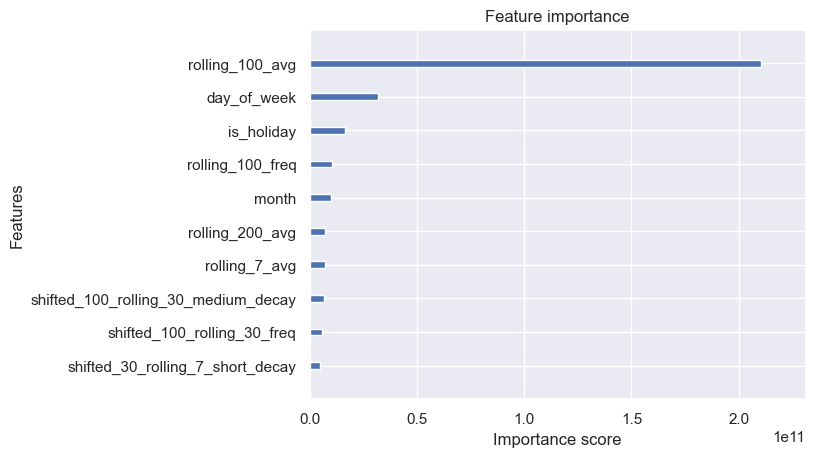

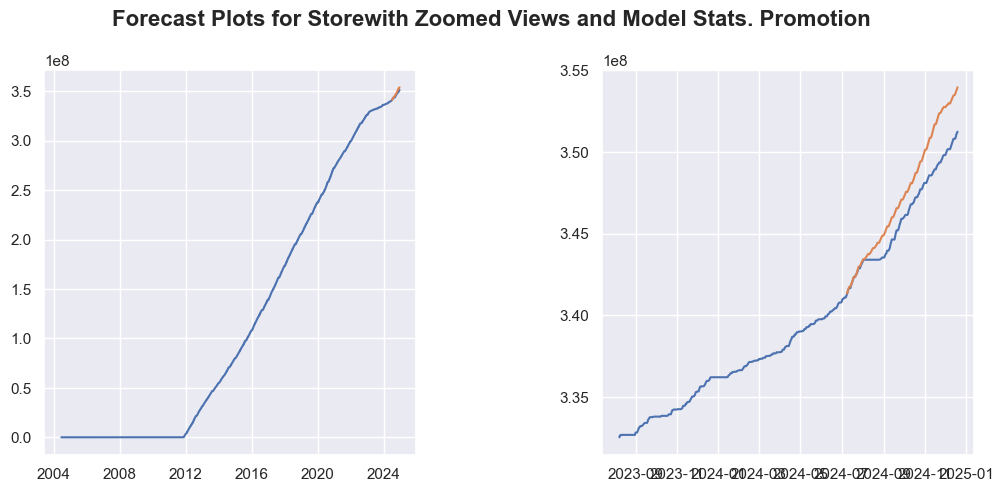

[I 2025-11-07 17:21:21,147] A new study created in memory with name: no-name-067bd873-71dc-42f9-ad75-aa566b30aebc
Best trial: 0. Best value: 45203.8: 100%|██████████| 1/1 [00:05<00:00,  5.71s/it]


[I 2025-11-07 17:21:26,854] Trial 0 finished with value: 45203.795702484524 and parameters: {'max_depth': 8, 'learning_rate': 0.06442836820576939, 'n_estimators': 920, 'subsample': 0.7406090142831061, 'colsample_bytree': 0.5164446704068224, 'reg_alpha': 0.32515976210389275, 'reg_lambda': 0.24395759363388914}. Best is trial 0 with value: 45203.795702484524.
Best parameters: {'max_depth': 8, 'learning_rate': 0.06442836820576939, 'n_estimators': 920, 'subsample': 0.7406090142831061, 'colsample_bytree': 0.5164446704068224, 'reg_alpha': 0.32515976210389275, 'reg_lambda': 0.24395759363388914}
future- apply predict to map: Check!
1
351244347.0


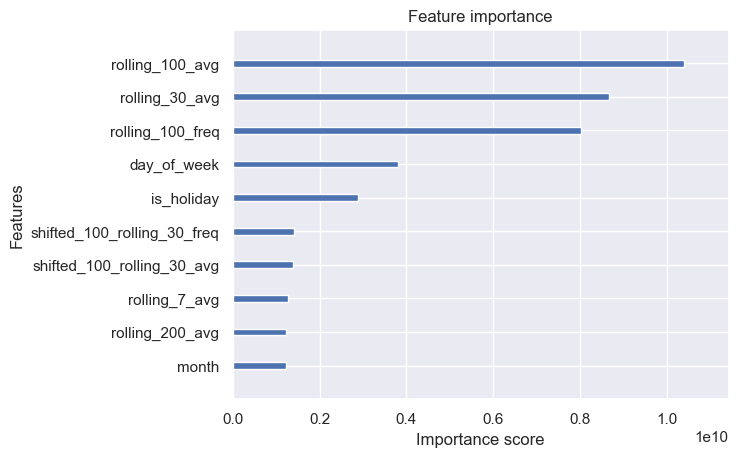

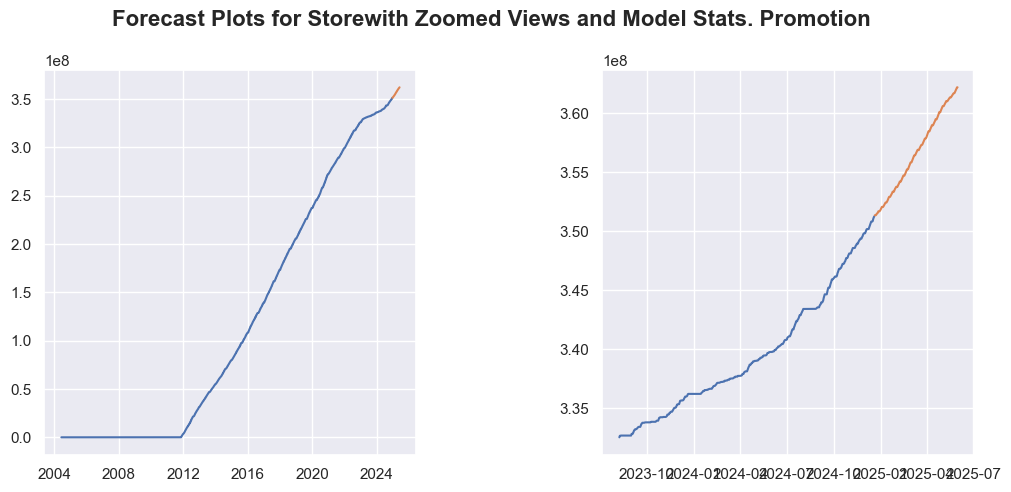

True

In [ ]:
#MAIN.
IMPORTANT_DAYS = 1000
IMPORTANT_IDS = range(0,1,1) #predict the most important IDs, ranging from start to finish.
#submission_df = pd.read.csv("data/prediction_mapping.csv")

run(clean_df, IMPORTANT_DAYS, IMPORTANT_IDS, feature_columns, target)



